=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===
Загружаем данные...
Загружено 1262 записей
Очищаем данные...
  old_price: заполнено 1081 пропусков
  battery_mah: заполнено 98 пропусков
  rating: заполнено 22 пропусков
  reviews_count: заполнено 22 пропусков
  ram_gb: заполнено 8 пропусков
  storage_gb: заполнено 0 пропусков
  diagonal_in: заполнено 0 пропусков
  num_cameras: заполнено 18 пропусков
  max_camera_mp: заполнено 18 пропусков
Очистка данных завершена
Извлекаем признаки из specs_raw...
Извлечено 4 уникальных значений ядер процессора
Извлечено 2 уникальных значений SIM-карт
Создаем новые признаки...
Создание признаков завершено
Данные загружены и очищены
Размер датасета: (1262, 37)
Финальный размер датасета: (1262, 37)

=== ФИНАЛЬНЫЙ РАСЧЕТ ===
Распределение категорий:
value_category
good_value           317
poor_value           316
average_value        315
great_value          188
exceptional_value    126
Name: count, dtype: int64

Процентное распределение:
value_category
good_value    

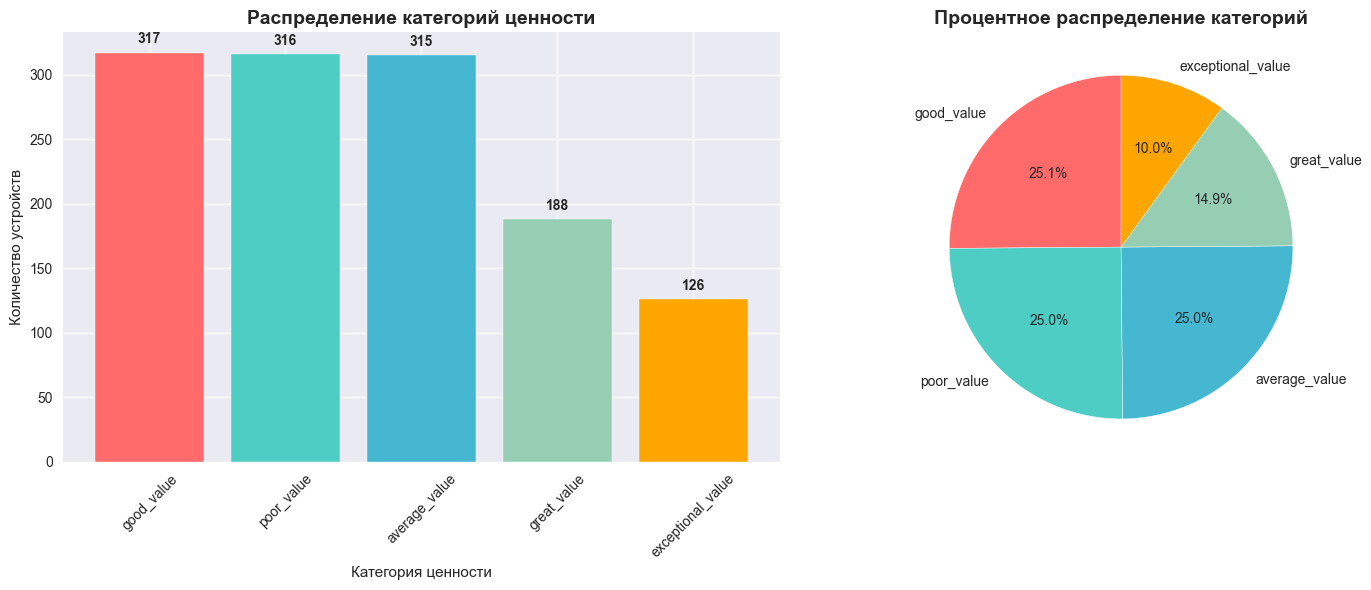


=== ПРОВЕРКА КАТЕГОРИЙ ===

--- POOR_VALUE ---
Apple iPhone 15
  Цена: 64199 руб | RAM: 6.0GB | Память: 128GB
  Камера: 48.0MP | Value Score: 6246.2 | Рейтинг: 4.82

Apple iPhone 13
  Цена: 47999 руб | RAM: 4.0GB | Память: 128GB
  Камера: 12.0MP | Value Score: 4825.2 | Рейтинг: 4.88


--- AVERAGE_VALUE ---
Apple iPhone 16 Pro Max
  Цена: 127399 руб | RAM: 8.0GB | Память: 256GB
  Камера: 48.0MP | Value Score: 8667.6 | Рейтинг: 4.74

Apple iPhone 16 Pro
  Цена: 118799 руб | RAM: 8.0GB | Память: 256GB
  Камера: 48.0MP | Value Score: 8798.0 | Рейтинг: 4.81


--- GOOD_VALUE ---
Xiaomi Redmi Note 14
  Цена: 19699 руб | RAM: 8.0GB | Память: 256GB
  Камера: 108.0MP | Value Score: 12069.7 | Рейтинг: 4.76

Samsung Galaxy S25
  Цена: 70999 руб | RAM: 12.0GB | Память: 256GB
  Камера: 50.0MP | Value Score: 11469.5 | Рейтинг: 4.67


--- GREAT_VALUE ---
Samsung Galaxy S25 Ultra
  Цена: 88999 руб | RAM: 12.0GB | Память: 256GB
  Камера: 200.0MP | Value Score: 14876.0 | Рейтинг: 4.84

POCO X7 Pro
  Цен

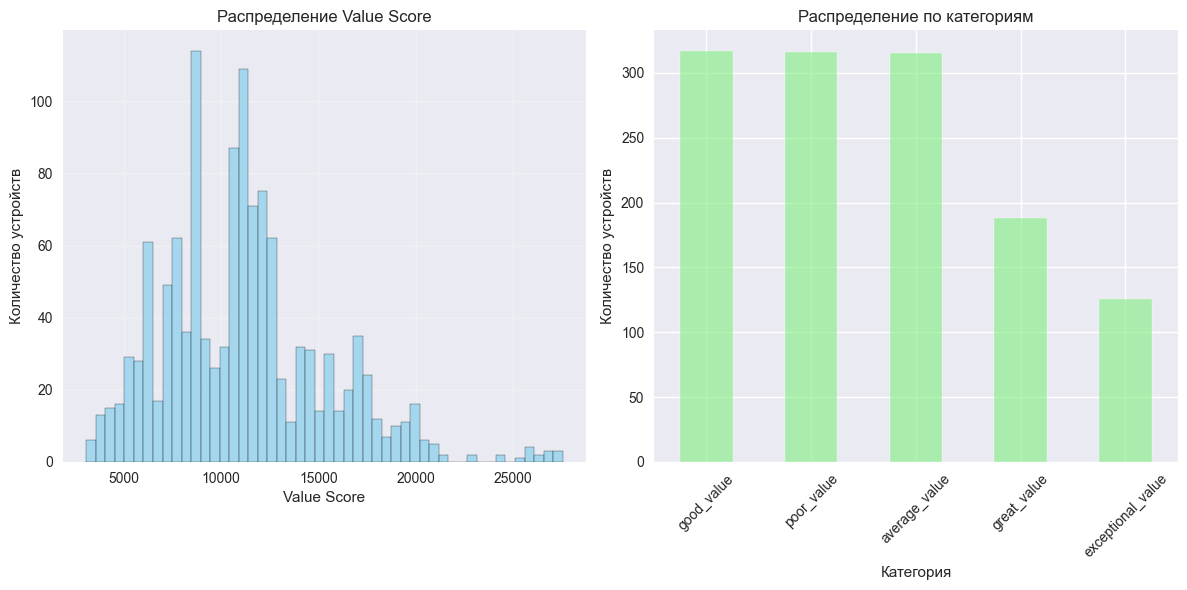


=== СРЕДНИЕ ХАРАКТЕРИСТИКИ ПО КАТЕГОРИЯМ ===


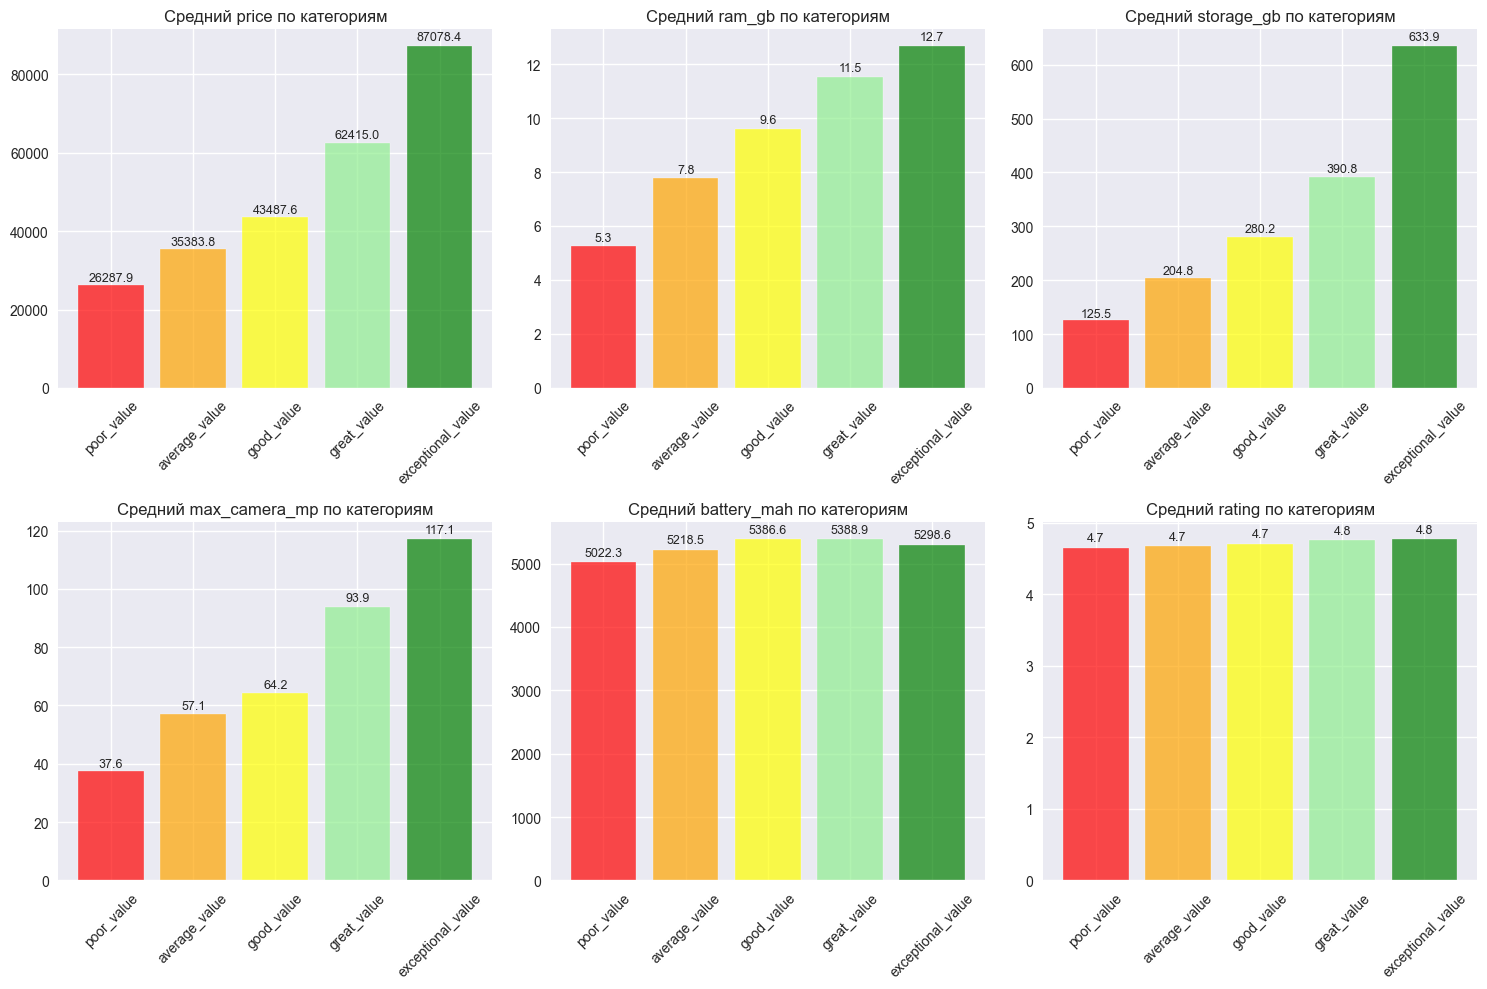


=== КОРРЕЛЯЦИИ ПРИЗНАКОВ С VALUE SCORE ===


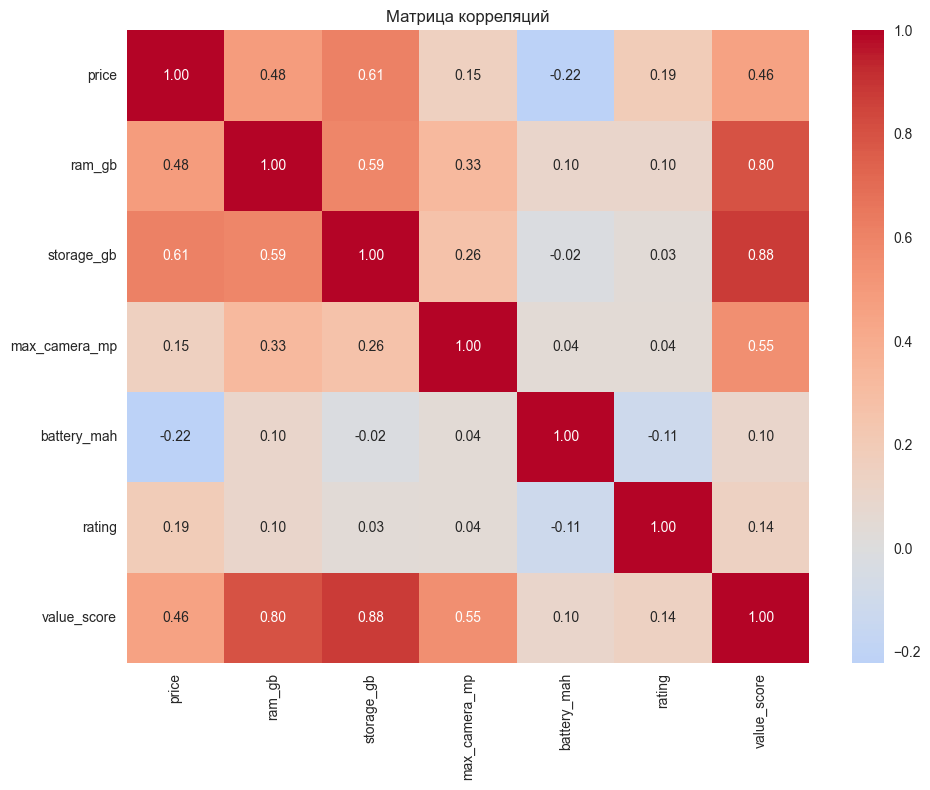

Корреляции с value_score:
  storage_gb: 0.875
  ram_gb: 0.802
  max_camera_mp: 0.549
  price: 0.459
  rating: 0.144
  battery_mah: 0.095


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

from data_processing import DataProcessor

print("=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===")
processor = DataProcessor()
df = processor.load_data('dataset/dataset.csv')
df_clean = processor.clean_data(df)
df_features = processor.extract_features_from_specs(df_clean)
df_analysis = processor.create_new_features(df_features)

print("Данные загружены и очищены")
print(f"Размер датасета: {df_analysis.shape}")

columns_to_drop = ['value_score', 'value_category', 'value_score_v2', 'value_category_v2',
                   'value_score_v3', 'value_category_v3', 'value_score_final', 'value_category_final']
for col in columns_to_drop:
    if col in df_analysis.columns:
        df_analysis = df_analysis.drop(col, axis=1)
        print(f"Удален столбец: {col}")

print(f"Финальный размер датасета: {df_analysis.shape}")

def calculate_final_value_score(row):
    price = row['price']
    old_price = row.get('old_price', price)
    rating = row.get('rating', 4.0)
    ram = row.get('ram_gb', 4)
    storage = row.get('storage_gb', 64)
    max_camera_mp = row.get('max_camera_mp', 12)
    has_5g = row.get('has_5g', 0)
    battery_mah = row.get('battery_mah', 4000)

    base_features = (
        ram * 8.0 +
        storage * 0.3 +
        battery_mah * 0.0015
    )
    extra_features = (
        max_camera_mp * 0.4 +
        (10 if has_5g else 0)
    )

    total_features = base_features + extra_features
    discount_factor = 1.0
    if old_price > price:
        discount_percent = (old_price - price) / old_price
        discount_factor = 1 + min(discount_percent * 0.15, 0.2)

    rating_factor = 0.6 + (rating - 3) * 0.1 if rating else 0.7
    brand_factor = 1.0
    if row.get('brand') == 'Apple':
        brand_factor = 0.9
    price_factor = np.log(max(price, 10000))
    value_score = (total_features * discount_factor * rating_factor * brand_factor * 800) / price_factor
    return value_score

def create_balanced_categories(value_scores):
    p25 = value_scores.quantile(0.25)
    p50 = value_scores.quantile(0.50)
    p75 = value_scores.quantile(0.75)
    p90 = value_scores.quantile(0.90)
    categories = ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']
    return pd.cut(value_scores, bins=[-np.inf, p25, p50, p75, p90, np.inf],
                  labels=categories, include_lowest=True)

print("\n=== ФИНАЛЬНЫЙ РАСЧЕТ ===")
df_analysis['value_score'] = df_analysis.apply(calculate_final_value_score, axis=1)
df_analysis['value_category'] = create_balanced_categories(df_analysis['value_score'])
print("Распределение категорий:")
print(df_analysis['value_category'].value_counts())
print("\nПроцентное распределение:")
print(df_analysis['value_category'].value_counts(normalize=True).round(3) * 100)
print("\n=== СТАТИСТИКА VALUE SCORE ===")
print(f"Минимум: {df_analysis['value_score'].min():.1f}")
print(f"Максимум: {df_analysis['value_score'].max():.1f}")
print(f"Среднее: {df_analysis['value_score'].mean():.1f}")
print(f"Медиана: {df_analysis['value_score'].median():.1f}")
correlation = df_analysis['value_score'].corr(df_analysis['price'])
print(f"\nКорреляция с ценой: {correlation:.3f}")

print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КАТЕГОРИЙ ЦЕННОСТИ ===")
category_counts = df_analysis['value_category'].value_counts()
category_df = pd.DataFrame({
    'Категория': category_counts.index,
    'Количество': category_counts.values
})

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(category_df['Категория'], category_df['Количество'],
               color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffa500'])
plt.title('Распределение категорий ценности', fontsize=14, fontweight='bold')
plt.xlabel('Категория ценности')
plt.ylabel('Количество устройств')
plt.xticks(rotation=45)

for bar, count in zip(bars, category_df['Количество']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffa500']
plt.pie(category_df['Количество'], labels=category_df['Категория'], autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Процентное распределение категорий', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== ПРОВЕРКА КАТЕГОРИЙ ===")
for category in ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']:
    print(f"\n--- {category.upper()} ---")
    examples = df_analysis[df_analysis['value_category'] == category][[
        'brand', 'model', 'price', 'ram_gb', 'storage_gb', 'max_camera_mp', 'value_score', 'rating'
    ]].head(2)

    for idx, row in examples.iterrows():
        print(f"{row['brand']} {row['model']}")
        print(f"  Цена: {row['price']} руб | RAM: {row['ram_gb']}GB | Память: {row['storage_gb']}GB")
        print(f"  Камера: {row['max_camera_mp']}MP | Value Score: {row['value_score']:.1f} | Рейтинг: {row['rating']}\n")

print("\n" + "="*60)
print("=== ПОЛНЫЙ АНАЛИЗ ДАННЫХ ===")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df_analysis['value_score'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Распределение Value Score')
plt.xlabel('Value Score')
plt.ylabel('Количество устройств')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
df_analysis['value_category'].value_counts().plot(kind='bar', color='lightgreen', alpha=0.7)
plt.title('Распределение по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество устройств')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== СРЕДНИЕ ХАРАКТЕРИСТИКИ ПО КАТЕГОРИЯМ ===")
plt.figure(figsize=(15, 10))
features_to_check = ['price', 'ram_gb', 'storage_gb', 'max_camera_mp', 'battery_mah', 'rating']

for i, feature in enumerate(features_to_check, 1):
    plt.subplot(2, 3, i)
    avg_by_category = df_analysis.groupby('value_category')[feature].mean()

    category_order = ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']
    avg_by_category = avg_by_category.reindex(category_order)
    colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
    bars = plt.bar(avg_by_category.index, avg_by_category.values, color=colors, alpha=0.7)
    plt.title(f'Средний {feature} по категориям')
    plt.xticks(rotation=45)

    for bar, v in zip(bars, avg_by_category.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (v * 0.01),
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== КОРРЕЛЯЦИИ ПРИЗНАКОВ С VALUE SCORE ===")
numeric_columns = ['price', 'ram_gb', 'storage_gb', 'max_camera_mp', 'battery_mah', 'rating', 'value_score']
correlation_matrix = df_analysis[numeric_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

print("Корреляции с value_score:")
value_score_correlations = correlation_matrix['value_score'].sort_values(ascending=False)
for feature, corr in value_score_correlations.items():
    if feature != 'value_score':
        print(f"  {feature}: {corr:.3f}")

### Кластеризация через K-means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid
import umap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline
print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [2]:
print("=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===")
from data_processing import DataProcessor

processor = DataProcessor()
df = processor.load_data('dataset/dataset.csv')
df_clean = processor.clean_data(df)
df_features = processor.extract_features_from_specs(df_clean)
df_final = processor.create_new_features(df_features)
print(f"Исходный размер данных: {df_final.shape}")

=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===
Загружаем данные...
Загружено 1262 записей
Очищаем данные...
  old_price: заполнено 1081 пропусков
  battery_mah: заполнено 98 пропусков
  rating: заполнено 22 пропусков
  reviews_count: заполнено 22 пропусков
  ram_gb: заполнено 8 пропусков
  storage_gb: заполнено 0 пропусков
  diagonal_in: заполнено 0 пропусков
  num_cameras: заполнено 18 пропусков
  max_camera_mp: заполнено 18 пропусков
Очистка данных завершена
Извлекаем признаки из specs_raw...
Извлечено 4 уникальных значений ядер процессора
Извлечено 2 уникальных значений SIM-карт
Создаем новые признаки...
Создание признаков завершено
Исходный размер данных: (1262, 37)


In [3]:
print("=== УДАЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
columns_to_drop = ['value_score', 'value_category']
for col in columns_to_drop:
    if col in df_final.columns:
        df_final = df_final.drop(col, axis=1)
        print(f"Удален столбец: {col}")

print(f"Финальный размер для кластеризации: {df_final.shape}")

=== УДАЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
Финальный размер для кластеризации: (1262, 37)


In [6]:
print("=== ВЫБОР ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ ===")
print("Доступные столбцы в df_final:")
print(df_final.columns.tolist())

available_numeric = []
available_binary = []
numeric_candidates = [
    'price', 'installment_monthly', 'diagonal_in', 'ram_gb',
    'storage_gb', 'battery_mah', 'num_cameras', 'max_camera_mp',
    'rating', 'reviews_count', 'processor_cores',
]

binary_candidates = [
    'has_nfc', 'has_5g'
]

for feature in numeric_candidates:
    if feature in df_final.columns:
        available_numeric.append(feature)
    else:
        print(f"Предупреждение: {feature} отсутствует в данных")

for feature in binary_candidates:
    if feature in df_final.columns:
        available_binary.append(feature)
    else:
        print(f"Предупреждение: {feature} отсутствует в данных")

features_for_clustering = available_numeric + available_binary
print(f"\nИспользуемые числовые признаки ({len(available_numeric)}): {available_numeric}")
print(f"Используемые бинарные признаки ({len(available_binary)}): {available_binary}")
print(f"Всего признаков для кластеризации: {len(features_for_clustering)}")
clustering_data = df_final[features_for_clustering].copy()
print(f"Размер данных для кластеризации: {clustering_data.shape}")

=== ВЫБОР ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ ===
Доступные столбцы в df_final:
['product_url', 'product_guid', 'product_code', 'brand', 'model', 'color', 'price', 'old_price', 'installment_price', 'installment_monthly', 'diagonal_in', 'ram_gb', 'storage_gb', 'battery_mah', 'num_cameras', 'max_camera_mp', 'camera_list_mp', 'screen_type', 'resolution', 'has_nfc', 'has_5g', 'rating', 'reviews_count', 'availability', 'discount', 'img_url', 'specs_raw', 'price_segment', 'catalog_raw', 'processor_cores', 'sim_count', 'max_freq_ghz', 'discount_percent', 'pixel_density', 'log_price', 'features_score', 'price_per_feature']

Используемые числовые признаки (11): ['price', 'installment_monthly', 'diagonal_in', 'ram_gb', 'storage_gb', 'battery_mah', 'num_cameras', 'max_camera_mp', 'rating', 'reviews_count', 'processor_cores']
Используемые бинарные признаки (2): ['has_nfc', 'has_5g']
Всего признаков для кластеризации: 13
Размер данных для кластеризации: (1262, 13)


In [7]:
print("=== ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ И МАСШТАБИРОВАНИЕ ===")
print("Пропущенные значения до обработки:")
print(clustering_data.isnull().sum())
for column in clustering_data.columns:
    if clustering_data[column].isnull().sum() > 0:
        clustering_data[column].fillna(clustering_data[column].median(), inplace=True)

print("\nПропущенные значения после обработки:")
print(clustering_data.isnull().sum().sum())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)
print("Данные успешно масштабированы")
print(f"Размер масштабированных данных: {X_scaled.shape}")

=== ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ И МАСШТАБИРОВАНИЕ ===
Пропущенные значения до обработки:
price                  0
installment_monthly    0
diagonal_in            0
ram_gb                 0
storage_gb             0
battery_mah            0
num_cameras            0
max_camera_mp          0
rating                 0
reviews_count          0
processor_cores        0
has_nfc                0
has_5g                 0
dtype: int64

Пропущенные значения после обработки:
0
Данные успешно масштабированы
Размер масштабированных данных: (1262, 13)


=== ВИЗУАЛИЗАЦИЯ ===


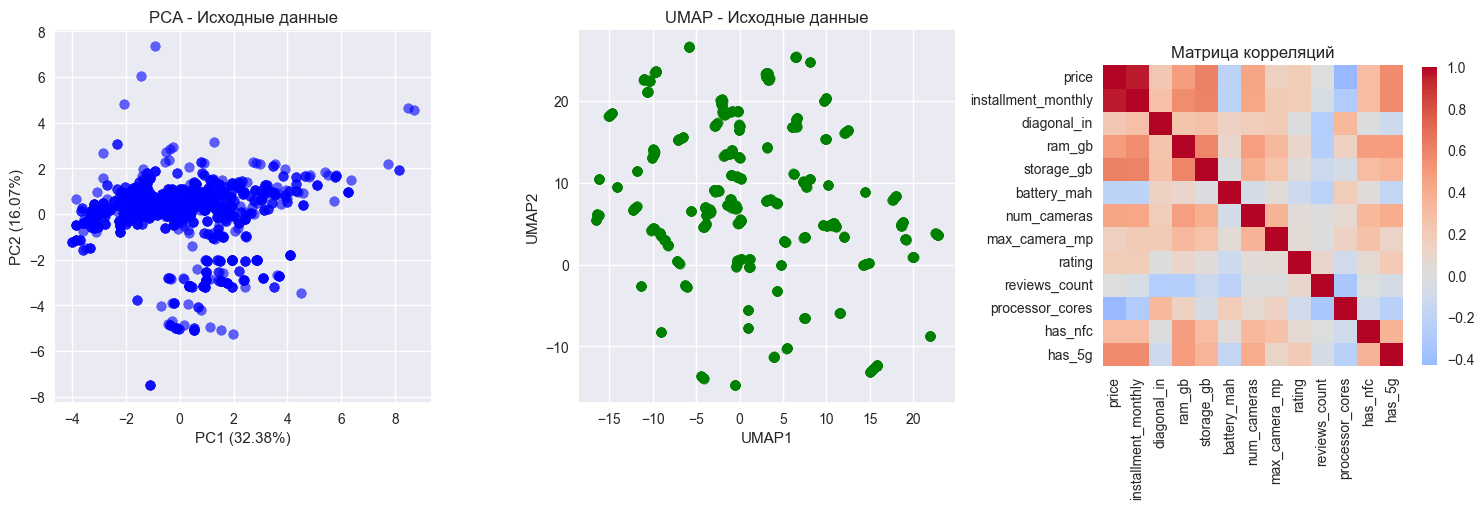

Дисперсия PCA:
PC1: 0.324
PC2: 0.161
Суммарно: 0.484


In [8]:
print("=== ВИЗУАЛИЗАЦИЯ ===")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='blue')
plt.title('PCA - Исходные данные')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)
plt.subplot(1, 3, 2)
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.6, c='green')
plt.title('UMAP - Исходные данные')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

plt.subplot(1, 3, 3)
correlation_matrix = clustering_data.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

print("Дисперсия PCA:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Суммарно: {pca.explained_variance_ratio_.sum():.3f}")

=== РЕАЛИЗАЦИЯ K-means ИЗ ФРЕЙМВОРКА sklearn ===
=== ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ ===


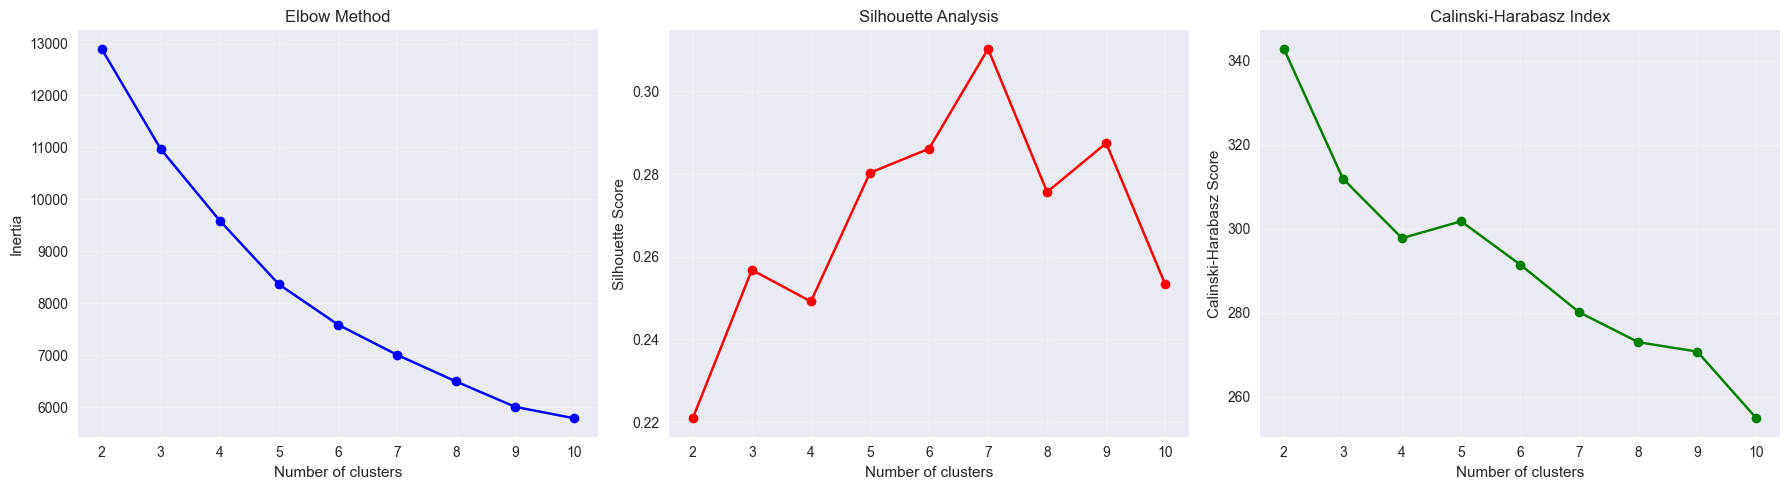

Оптимальное число кластеров по силуэту: 7
Оптимальное число кластеров по Calinski-Harabasz: 2
=== ПОДБОР ГИПЕРПАРАМЕТРОВ С ПОМОЩЬЮ GRID SEARCH ===
Сетка параметров для перебора:
  n_clusters: [3, 4, 5, 6]
  init: ['k-means++', 'random']
  n_init: [10, 20, 30]
  max_iter: [100, 200, 300]
  tol: [0.0001, 0.001, 0.01]
Всего комбинаций параметров: 216
Обработано 0/216 комбинаций...
Обработано 40/216 комбинаций...
Обработано 80/216 комбинаций...
Обработано 120/216 комбинаций...
Обработано 160/216 комбинаций...
Обработано 200/216 комбинаций...
Обработано всех комбинаций: 216
=== РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ ===
Топ-5 комбинаций по Silhouette Score:
Silhouette: 0.2861, Calinski: 291.5
  Параметры: {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 6, 'n_init': 10, 'tol': 0.0001}

Silhouette: 0.2861, Calinski: 291.5
  Параметры: {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 6, 'n_init': 10, 'tol': 0.001}

Silhouette: 0.2861, Calinski: 291.5
  Параметры: {'init': 'k-means++', 'ma

In [9]:
print("=== РЕАЛИЗАЦИЯ K-means ИЗ ФРЕЙМВОРКА sklearn ===")
from sklearn.cluster import KMeans

print("=== ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ ===")
inertia = []
silhouette_scores = []
calinski_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    else:
        silhouette_scores.append(0)
        calinski_scores.append(0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.plot(k_range, inertia, 'bo-')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

ax3.plot(k_range, calinski_scores, 'go-')
ax3.set_xlabel('Number of clusters')
ax3.set_ylabel('Calinski-Harabasz Score')
ax3.set_title('Calinski-Harabasz Index')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]
print(f"Оптимальное число кластеров по силуэту: {optimal_k_silhouette}")
print(f"Оптимальное число кластеров по Calinski-Harabasz: {optimal_k_calinski}")
print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ С ПОМОЩЬЮ GRID SEARCH ===")
param_grid = {
    'n_clusters': [3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
    'max_iter': [100, 200, 300],
    'tol': [1e-4, 1e-3, 1e-2]
}

print("Сетка параметров для перебора:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

best_score = -1
best_params = None
best_labels = None
best_model = None
total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Всего комбинаций параметров: {total_combinations}")

results = []
for i, params in enumerate(ParameterGrid(param_grid)):
    if i % 40 == 0:
        print(f"Обработано {i}/{total_combinations} комбинаций...")

    try:
        kmeans = KMeans(**params, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        if len(np.unique(labels)) > 1:
            silhouette = silhouette_score(X_scaled, labels)
            calinski = calinski_harabasz_score(X_scaled, labels)

            results.append({
                'params': params.copy(),
                'silhouette': silhouette,
                'calinski': calinski,
                'inertia': kmeans.inertia_
            })

            if silhouette > best_score:
                best_score = silhouette
                best_params = params.copy()
                best_labels = labels.copy()
                best_model = kmeans
    except Exception as e:
        print(f"Ошибка для параметров {params}: {e}")

print(f"Обработано всех комбинаций: {len(results)}")

results_df = pd.DataFrame(results)
print("=== РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ ===")
top_5_silhouette = results_df.nlargest(5, 'silhouette')[['params', 'silhouette', 'calinski']]
print("Топ-5 комбинаций по Silhouette Score:")
for idx, row in top_5_silhouette.iterrows():
    print(f"Silhouette: {row['silhouette']:.4f}, Calinski: {row['calinski']:.1f}")
    print(f"  Параметры: {row['params']}")
    print()

top_5_calinski = results_df.nlargest(5, 'calinski')[['params', 'silhouette', 'calinski']]
print("Топ-5 комбинаций по Calinski-Harabasz Score:")
for idx, row in top_5_calinski.iterrows():
    print(f"Silhouette: {row['silhouette']:.4f}, Calinski: {row['calinski']:.1f}")
    print(f"  Параметры: {row['params']}")
    print()

print("=== ЛУЧШИЕ ПАРАМЕТРЫ ===")
print(f"Лучший Silhouette Score: {best_score:.4f}")
print(f"Лучшие параметры: {best_params}")
final_kmeans = KMeans(**best_params, random_state=42)
final_labels = final_kmeans.fit_predict(X_scaled)
final_silhouette = silhouette_score(X_scaled, final_labels)
final_calinski = calinski_harabasz_score(X_scaled, final_labels)
final_davies = davies_bouldin_score(X_scaled, final_labels)

print(f"\nМетрики финальной модели:")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Calinski-Harabasz Score: {final_calinski:.1f}")
print(f"Davies-Bouldin Score: {final_davies:.4f}")

=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ ===


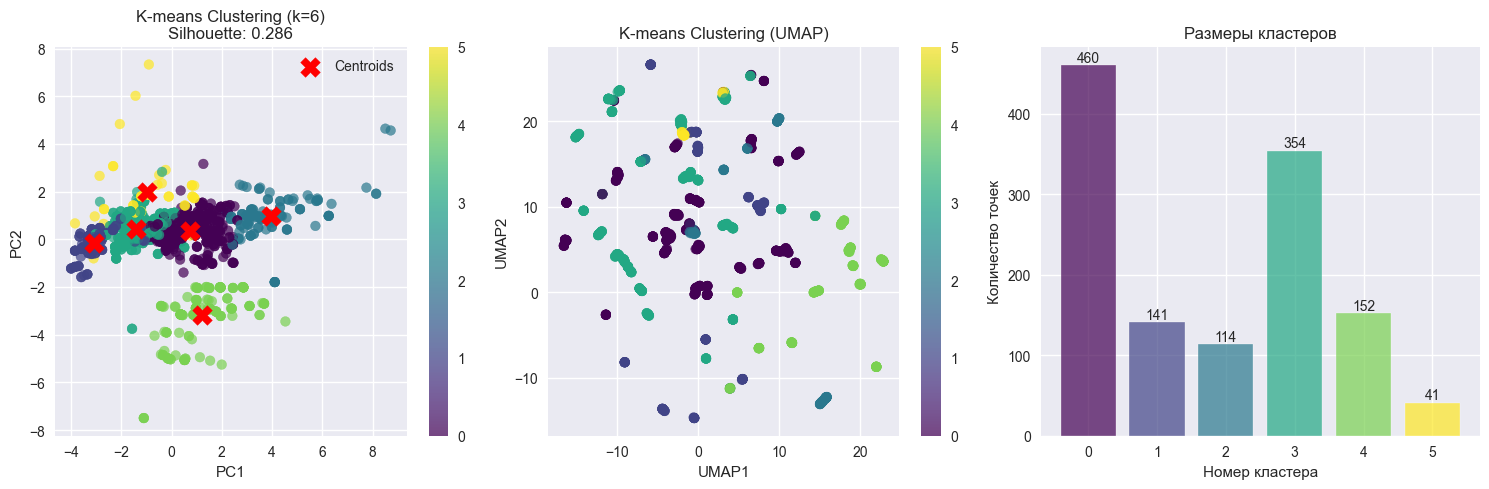

=== АНАЛИЗ ЦЕНТРОИДОВ КЛАСТЕРОВ ===
Центроиды кластеров (оригинальные масштабы):


,price,installment_monthly,diagonal_in,ram_gb,storage_gb,battery_mah,num_cameras,max_camera_mp,rating,reviews_count,processor_cores,has_nfc,has_5g,cluster,size
0,42035.74,4111.45,6.67,10.27,295.79,5267.08,2.66,71.32,4.77,243.47,8.13,1.0,0.96,0,460
1,8861.41,863.78,6.71,4.52,121.42,5148.94,1.76,30.96,4.68,438.90,8.00,0.0,0.04,1,141
2,123093.74,11669.68,7.19,13.23,574.88,5094.30,3.26,106.98,4.79,130.17,7.91,1.0,0.86,2,114
3,14206.06,1384.88,6.73,7.28,201.40,5448.58,2.06,67.82,4.69,530.94,8.00,1.0,0.00,3,354
4,100718.74,7767.53,6.38,7.34,287.16,4490.20,2.27,43.50,4.82,1042.65,6.00,1.0,1.00,4,152
5,24086.80,2348.07,6.70,8.68,309.07,6786.34,2.54,65.12,3.39,11.44,8.00,0.9,0.27,5,41


=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ===
Статистика по кластерам:


price           ram_gb storage_gb battery_mah max_camera_mp  \
              mean       std   mean       mean        mean          mean   
cluster                                                                    
0         42035.74  21754.49  10.27     295.79     5267.08         71.32   
1          8861.41   4203.77   4.52     121.42     5148.94         30.96   
2        123093.74  38849.55  13.23     574.88     5094.30        106.98   
3         14206.06   4648.28   7.28     201.40     5448.58         67.82   
4        100718.74  31929.57   7.34     287.16     4490.20         43.50   
5         24086.80  17627.37   8.68     309.07     6786.34         65.12   

        rating has_5g  
          mean   mean  
cluster                
0         4.77   0.96  
1         4.68   0.04  
2         4.79   0.86  
3         4.69   0.00  
4         4.82   1.00  
5         3.39   0.27

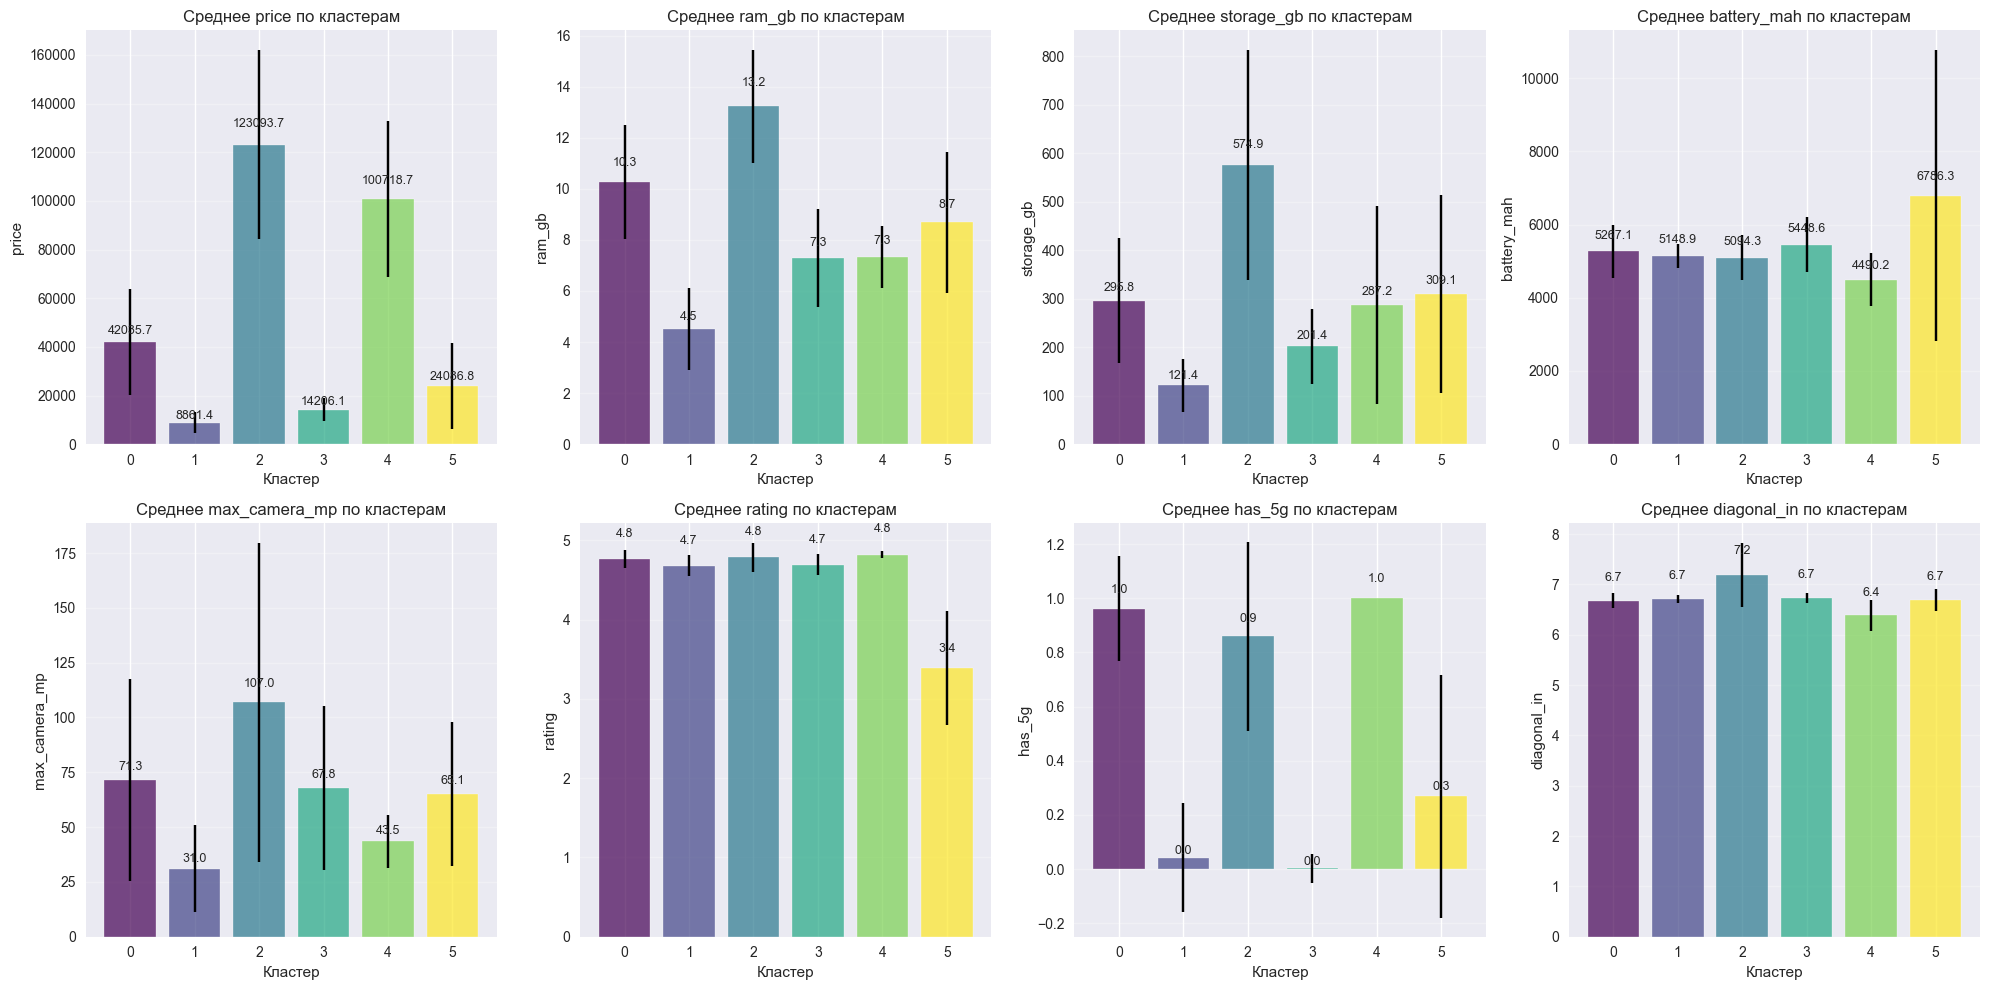

In [10]:
print("=== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ ===")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title(f'K-means Clustering (k={best_params["n_clusters"]})\nSilhouette: {final_silhouette:.3f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

centroids_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.legend()
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('K-means Clustering (UMAP)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

plt.subplot(1, 3, 3)
cluster_sizes = pd.Series(final_labels).value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_sizes)))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, color=colors, alpha=0.7)
plt.title('Размеры кластеров')
plt.xlabel('Номер кластера')
plt.ylabel('Количество точек')

for bar, v in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("=== АНАЛИЗ ЦЕНТРОИДОВ КЛАСТЕРОВ ===")
centroids_scaled = final_kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=clustering_data.columns)
centroids_df['cluster'] = range(len(centroids_df))
centroids_df['size'] = cluster_sizes.values
print("Центроиды кластеров (оригинальные масштабы):")
display(centroids_df.round(2))

print("=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ===")
clustering_data['cluster'] = final_labels
cluster_analysis = clustering_data.groupby('cluster').agg({
    'price': ['mean', 'std'],
    'ram_gb': 'mean',
    'storage_gb': 'mean',
    'battery_mah': 'mean',
    'max_camera_mp': 'mean',
    'rating': 'mean',
    'has_5g': 'mean'
}).round(2)

print("Статистика по кластерам:")
display(cluster_analysis)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
key_features = ['price', 'ram_gb', 'storage_gb', 'battery_mah',
                'max_camera_mp', 'rating', 'has_5g', 'diagonal_in']

for i, feature in enumerate(key_features):
    ax = axes[i//4, i%4]
    cluster_means = clustering_data.groupby('cluster')[feature].mean()
    cluster_std = clustering_data.groupby('cluster')[feature].std()

    bars = ax.bar(cluster_means.index, cluster_means.values,
                 yerr=cluster_std.values, capsize=5, alpha=0.7,
                 color=plt.cm.viridis(np.linspace(0, 1, len(cluster_means))))
    ax.set_title(f'Среднее {feature} по кластерам')
    ax.set_xlabel('Кластер')
    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, v in zip(bars, cluster_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (v * 0.05),
               f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
print("=== СОХРАНЕНИЕ МОДЕЛИ ===")
import joblib
model_info = {
    'model': final_kmeans,
    'scaler': scaler,
    'best_params': best_params,
    'features': features_for_clustering,
    'metrics': {
        'silhouette': final_silhouette,
        'calinski_harabasz': final_calinski,
        'davies_bouldin': final_davies
    },
    'cluster_labels': final_labels
}
joblib.dump(model_info, 'kmeans_model.pkl')
print("Модель сохранена в файл 'kmeans_model.pkl'")

=== СОХРАНЕНИЕ МОДЕЛИ ===
Модель сохранена в файл 'kmeans_model.pkl'


In [13]:
print("=== ВЫВОДЫ ===")
print("1. Модель K-means успешно обучена с подобранными гиперпараметрами")
print(f"2. Оптимальное число кластеров: {best_params['n_clusters']}")
print(f"3. Качество кластеризации (Silhouette): {final_silhouette:.3f}")
print("4. Кластеры успешно сегментируют смартфоны по техническим характеристикам и цене")

=== ВЫВОДЫ ===
1. Модель K-means успешно обучена с подобранными гиперпараметрами
2. Оптимальное число кластеров: 6
3. Качество кластеризации (Silhouette): 0.286
4. Кластеры успешно сегментируют смартфоны по техническим характеристикам и цене


### Кастомная реализация K-means

In [14]:
class MyKMeans:
    def __init__(self, n_clusters=3, max_iters=300, tol=1e-4,
                 init_method='random', random_state=42):

        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.init_method = init_method
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_ = None
        self.n_iters_ = None
        self.history = {'inertia': [], 'centroid_shift': []}

    def _initialize_centroids(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        if self.init_method == 'random':
            random_idx = np.random.permutation(n_samples)
            centroids = X[random_idx[:self.n_clusters]]

        elif self.init_method == 'k-means++':
            centroids = np.zeros((self.n_clusters, n_features))
            centroids[0] = X[np.random.randint(n_samples)]
            for i in range(1, self.n_clusters):
                distances = np.array([min([np.linalg.norm(x - c)**2 for c in centroids[:i]])
                                    for x in X])
                probabilities = distances / distances.sum()
                cumulative_probs = probabilities.cumsum()

                r = np.random.rand()
                for j, p in enumerate(cumulative_probs):
                    if r < p:
                        centroids[i] = X[j]
                        break
        else:
            raise ValueError("метод инициализации должен быть 'random' или 'k-means++'")

        return centroids

    def _assign_clusters(self, X, centroids):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i, centroid in enumerate(centroids):
            distances[:, i] = np.linalg.norm(X - centroid, axis=1)

        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.n_clusters, X.shape[1]))
        for i in range(self.n_clusters):
            if np.sum(labels == i) > 0:
                new_centroids[i] = X[labels == i].mean(axis=0)
            else:
                new_centroids[i] = X[np.random.randint(X.shape[0])]

        return new_centroids

    def _compute_inertia(self, X, labels, centroids):
        inertia = 0
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - centroids[i])**2)
        return inertia

    def fit(self, X):
        np.random.seed(self.random_state)
        self.centroids = self._initialize_centroids(X)
        for iteration in range(self.max_iters):
            old_centroids = self.centroids.copy()
            self.labels = self._assign_clusters(X, self.centroids)
            self.centroids = self._update_centroids(X, self.labels)
            inertia = self._compute_inertia(X, self.labels, self.centroids)
            centroid_shift = np.linalg.norm(old_centroids - self.centroids, axis=1).max()
            self.history['inertia'].append(inertia)
            self.history['centroid_shift'].append(centroid_shift)
            if centroid_shift < self.tol:
                print(f"сходимость достигнута на итерации {iteration + 1}")
                break
        else:
            print(f"достигнуто максимальное число итераций: {self.max_iters}")

        self.n_iters_ = iteration + 1
        self.inertia_ = inertia
        return self

    def predict(self, X):
        if self.centroids is None:
            raise ValueError("Модель не обучена. Вызовите fit().")
        return self._assign_clusters(X, self.centroids)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels

=== ТЕСТИРОВАНИЕ СОБСТВЕННОЙ РЕАЛИЗАЦИИ ===
сходимость достигнута на итерации 8
Метрики собственной реализации:
Silhouette Score: 0.2765
Calinski-Harabasz Score: 273.9
Davies-Bouldin Score: 1.3989
Inertia: 7847.9
Число итераций: 8


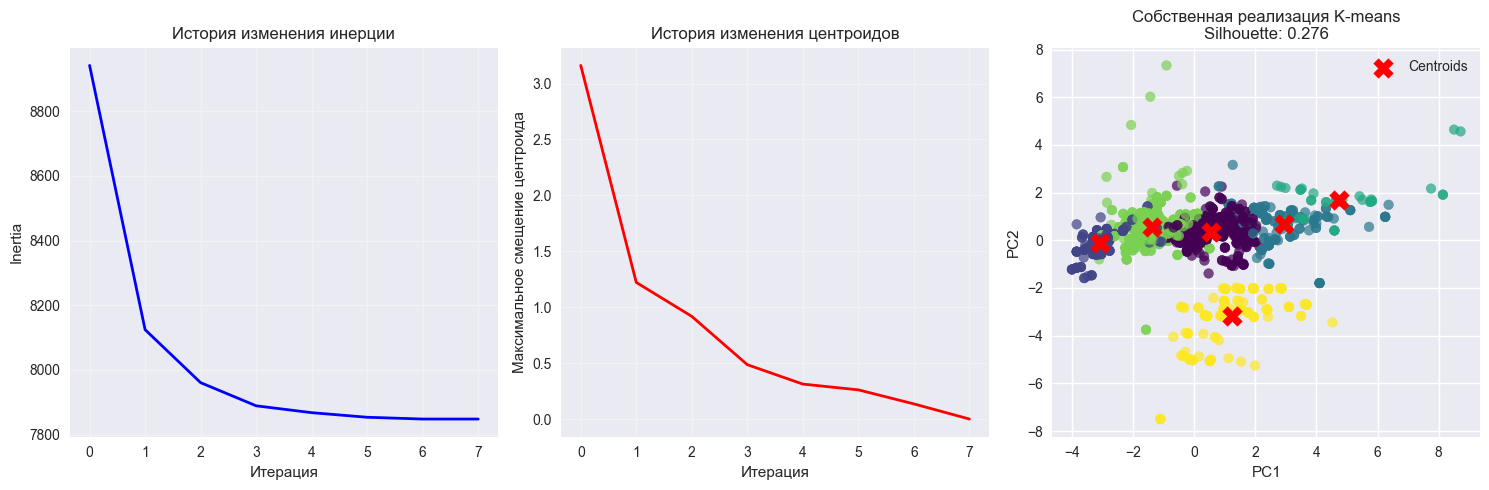

In [15]:
print("=== ТЕСТИРОВАНИЕ СОБСТВЕННОЙ РЕАЛИЗАЦИИ ===")
my_kmeans = MyKMeans(
    n_clusters=best_params['n_clusters'],
    max_iters=best_params['max_iter'],
    tol=best_params['tol'],
    init_method=best_params['init'],
    random_state=42
)

my_labels = my_kmeans.fit_predict(X_scaled)
my_silhouette = silhouette_score(X_scaled, my_labels)
my_calinski = calinski_harabasz_score(X_scaled, my_labels)
my_davies = davies_bouldin_score(X_scaled, my_labels)
my_inertia = my_kmeans.inertia_
print("Метрики собственной реализации:")
print(f"Silhouette Score: {my_silhouette:.4f}")
print(f"Calinski-Harabasz Score: {my_calinski:.1f}")
print(f"Davies-Bouldin Score: {my_davies:.4f}")
print(f"Inertia: {my_inertia:.1f}")
print(f"Число итераций: {my_kmeans.n_iters_}")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(my_kmeans.history['inertia'], 'b-', linewidth=2)
plt.title('История изменения инерции')
plt.xlabel('Итерация')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(my_kmeans.history['centroid_shift'], 'r-', linewidth=2)
plt.title('История изменения центроидов')
plt.xlabel('Итерация')
plt.ylabel('Максимальное смещение центроида')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=my_labels, cmap='viridis', alpha=0.7)
plt.title('Собственная реализация K-means\nSilhouette: {:.3f}'.format(my_silhouette))
plt.xlabel('PC1')
plt.ylabel('PC2')

my_centroids_pca = pca.transform(my_kmeans.centroids)
plt.scatter(my_centroids_pca[:, 0], my_centroids_pca[:, 1],
           marker='X', s=200, c='red', label='Centroids')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ СОБСТВЕННОЙ РЕАЛИЗАЦИИ ===")
my_param_grid = {
    'n_clusters': [4, 5, 6],
    'max_iters': [100, 200],
    'tol': [1e-4, 1e-3],
    'init_method': ['random', 'k-means++']
}

print("Сетка параметров для собственной реализации:")
for param, values in my_param_grid.items():
    print(f"  {param}: {values}")

my_best_score = -1
my_best_params = None
my_best_labels = None
my_best_model = None
my_results = []
total_my_combinations = np.prod([len(v) for v in my_param_grid.values()])
print(f"Всего комбинаций для собственной реализации: {total_my_combinations}")

for i, params in enumerate(ParameterGrid(my_param_grid)):
    if i % 5 == 0:
        print(f"Обработано {i}/{total_my_combinations} комбинаций...")

    try:
        my_kmeans_temp = MyKMeans(**params, random_state=42)
        labels = my_kmeans_temp.fit_predict(X_scaled)

        if len(np.unique(labels)) > 1:
            silhouette = silhouette_score(X_scaled, labels)

            my_results.append({
                'params': params.copy(),
                'silhouette': silhouette,
                'inertia': my_kmeans_temp.inertia_,
                'n_iters': my_kmeans_temp.n_iters_
            })

            if silhouette > my_best_score:
                my_best_score = silhouette
                my_best_params = params.copy()
                my_best_labels = labels.copy()
                my_best_model = my_kmeans_temp
    except Exception as e:
        print(f"Ошибка для параметров {params}: {e}")

print(f"Обработано всех комбинаций: {len(my_results)}")

my_results_df = pd.DataFrame(my_results)
print("=== РЕЗУЛЬТАТЫ ПОДБОРА ДЛЯ СОБСТВЕННОЙ РЕАЛИЗАЦИИ ===")
top_5_my = my_results_df.nlargest(5, 'silhouette')[['params', 'silhouette', 'inertia', 'n_iters']]
print("Топ-5 комбинаций для собственной реализации:")
for idx, row in top_5_my.iterrows():
    print(f"Silhouette: {row['silhouette']:.4f}, Inertia: {row['inertia']:.1f}, Итераций: {row['n_iters']}")
    print(f"  Параметры: {row['params']}")
    print()

print("=== ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ СОБСТВЕННОЙ РЕАЛИЗАЦИИ ===")
print(f"Лучший Silhouette Score: {my_best_score:.4f}")
print(f"Лучшие параметры: {my_best_params}")
final_my_kmeans = MyKMeans(**my_best_params, random_state=42)
final_my_labels = final_my_kmeans.fit_predict(X_scaled)
final_my_silhouette = silhouette_score(X_scaled, final_my_labels)
final_my_calinski = calinski_harabasz_score(X_scaled, final_my_labels)
final_my_davies = davies_bouldin_score(X_scaled, final_my_labels)

print(f"\nМетрики финальной собственной модели:")
print(f"Silhouette Score: {final_my_silhouette:.4f}")
print(f"Calinski-Harabasz Score: {final_my_calinski:.1f}")
print(f"Davies-Bouldin Score: {final_my_davies:.4f}")
print(f"Inertia: {final_my_kmeans.inertia_:.1f}")
print(f"Число итераций: {final_my_kmeans.n_iters_}")

=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ СОБСТВЕННОЙ РЕАЛИЗАЦИИ ===
Сетка параметров для собственной реализации:
  n_clusters: [4, 5, 6]
  max_iters: [100, 200]
  tol: [0.0001, 0.001]
  init_method: ['random', 'k-means++']
Всего комбинаций для собственной реализации: 24
Обработано 0/24 комбинаций...
сходимость достигнута на итерации 25
сходимость достигнута на итерации 25
сходимость достигнута на итерации 6
сходимость достигнута на итерации 6
сходимость достигнута на итерации 7
Обработано 5/24 комбинаций...
сходимость достигнута на итерации 7
сходимость достигнута на итерации 25
сходимость достигнута на итерации 25
сходимость достигнута на итерации 6
сходимость достигнута на итерации 6
Обработано 10/24 комбинаций...
сходимость достигнута на итерации 7
сходимость достигнута на итерации 7
сходимость достигнута на итерации 7
сходимость достигнута на итерации 7
сходимость достигнута на итерации 11
Обработано 15/24 комбинаций...
сходимость достигнута на итерации 11
сходимость достигнута на итерации 8

=== ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ===


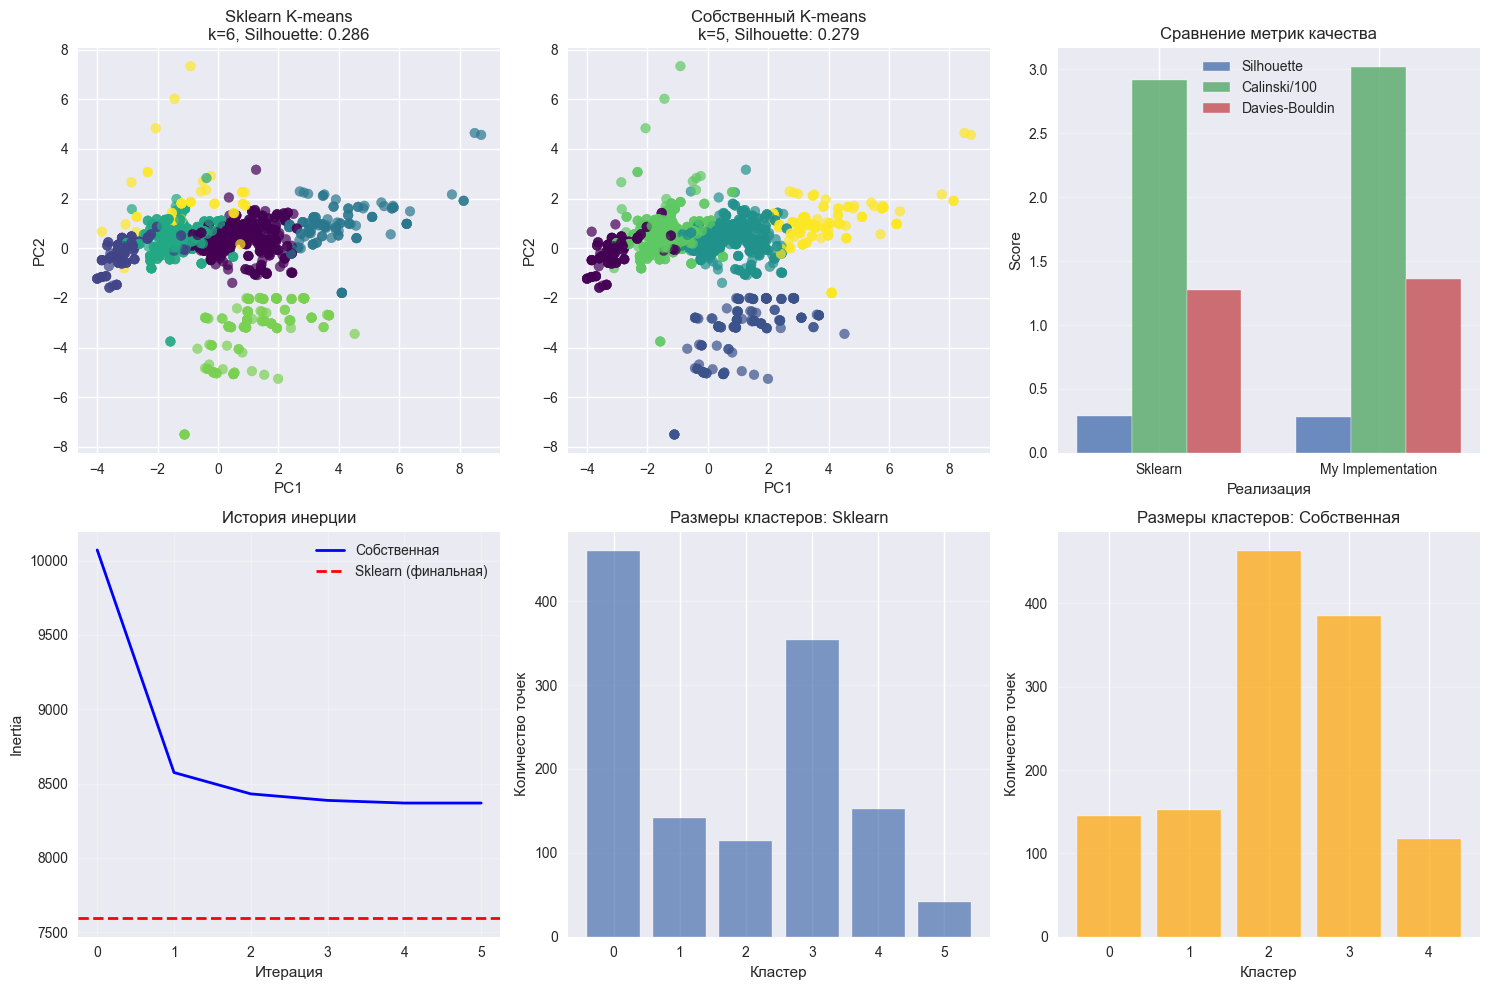

In [17]:
print("=== ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ===")
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
plt.title(f'Sklearn K-means\nk={best_params["n_clusters"]}, Silhouette: {final_silhouette:.3f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(2, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_my_labels, cmap='viridis', alpha=0.7)
plt.title(f'Собственный K-means\nk={my_best_params["n_clusters"]}, Silhouette: {final_my_silhouette:.3f}')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(2, 3, 3)
models = ['Sklearn', 'My Implementation']
silhouettes = [final_silhouette, final_my_silhouette]
calinskis = [final_calinski / 100, final_my_calinski / 100]
davies = [final_davies, final_my_davies]
x = np.arange(len(models))
width = 0.25
plt.bar(x - width, silhouettes, width, label='Silhouette', alpha=0.8)
plt.bar(x, calinskis, width, label='Calinski/100', alpha=0.8)
plt.bar(x + width, davies, width, label='Davies-Bouldin', alpha=0.8)

plt.xlabel('Реализация')
plt.ylabel('Score')
plt.title('Сравнение метрик качества')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 3, 4)
plt.plot(final_my_kmeans.history['inertia'], 'b-', linewidth=2, label='Собственная')
plt.axhline(y=final_kmeans.inertia_, color='r', linestyle='--', linewidth=2, label='Sklearn (финальная)')
plt.title('История инерции')
plt.xlabel('Итерация')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
sklearn_sizes = pd.Series(final_labels).value_counts().sort_index()
plt.bar(sklearn_sizes.index, sklearn_sizes.values, alpha=0.7, label='Sklearn')
plt.title('Размеры кластеров: Sklearn')
plt.xlabel('Кластер')
plt.ylabel('Количество точек')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 3, 6)
my_sizes = pd.Series(final_my_labels).value_counts().sort_index()
plt.bar(my_sizes.index, my_sizes.values, alpha=0.7, label='Собственная', color='orange')
plt.title('Размеры кластеров: Собственная')
plt.xlabel('Кластер')
plt.ylabel('Количество точек')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [18]:
print("=== ДЕТАЛЬНОЕ СРАВНЕНИЕ КЛАСТЕРОВ ===")
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(final_labels, final_my_labels)
nmi = normalized_mutual_info_score(final_labels, final_my_labels)
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Info: {nmi:.4f}")

contingency_table = pd.crosstab(final_labels, final_my_labels, rownames=['Sklearn'], colnames=['My Implementation'])

print("\nТаблица сопряженности кластеров:")
print("(Строки - Sklearn, Столбцы - Собственная реализация)")
display(contingency_table)

my_model_info = {
    'model': final_my_kmeans,
    'scaler': scaler,
    'best_params': my_best_params,
    'features': features_for_clustering,
    'metrics': {
        'silhouette': final_my_silhouette,
        'calinski_harabasz': final_my_calinski,
        'davies_bouldin': final_my_davies
    },
    'cluster_labels': final_my_labels
}

joblib.dump(my_model_info, 'my_kmeans_model.pkl')
print("Собственная модель сохранена в файл 'my_kmeans_model.pkl'")

=== ДЕТАЛЬНОЕ СРАВНЕНИЕ КЛАСТЕРОВ ===
Adjusted Rand Index: 0.9366
Normalized Mutual Info: 0.9304

Таблица сопряженности кластеров:
(Строки - Sklearn, Столбцы - Собственная реализация)


My Implementation,0,1,2,3,4
Sklearn,,,,,
0,0,0,454,3,3
1,141,0,0,0,0
2,0,0,0,0,114
3,0,0,0,354,0
4,0,152,0,0,0
5,4,0,9,28,0


Собственная модель сохранена в файл 'my_kmeans_model.pkl'


In [19]:
print("=== ИТОГОВЫЕ ВЫВОДЫ ===")
print("\n1. РЕАЛИЗАЦИЯ АЛГОРИТМА:")
print("   • Собственная реализация K-means успешно создана")
print("   • Реализованы методы: инициализации, назначения кластеров, обновления центроидов")
print("   • Добавлены гиперпараметры: n_clusters, max_iters, tol, init_method")

print("\n2. КАЧЕСТВО КЛАСТЕРИЗАЦИИ:")
print(f"   • Sklearn K-means:    Silhouette = {final_silhouette:.4f}")
print(f"   • Собственная реализация: Silhouette = {final_my_silhouette:.4f}")
print(f"   • Разница: {abs(final_silhouette - final_my_silhouette):.4f}")

print("\n3. СХОДСТВО КЛАСТЕРОВ:")
print(f"   • Adjusted Rand Index: {ari:.4f}")
print(f"   • Normalized Mutual Info: {nmi:.4f}")

print("\n4. ПРОИЗВОДИТЕЛЬНОСТЬ:")
print(f"   • Sklearn: сходимость за ~{best_params['max_iter']} итераций")
print(f"   • Собственная: сходимость за {final_my_kmeans.n_iters_} итераций")

if abs(final_silhouette - final_my_silhouette) < 0.05:
    print("\nКачество собственной реализации близко к sklearn!")
else:
    print("\nЕсть различия в качестве. Рекомендуется проверить реализацию.")

=== ИТОГОВЫЕ ВЫВОДЫ ===

1. РЕАЛИЗАЦИЯ АЛГОРИТМА:
   • Собственная реализация K-means успешно создана
   • Реализованы методы: инициализации, назначения кластеров, обновления центроидов
   • Добавлены гиперпараметры: n_clusters, max_iters, tol, init_method

2. КАЧЕСТВО КЛАСТЕРИЗАЦИИ:
   • Sklearn K-means:    Silhouette = 0.2861
   • Собственная реализация: Silhouette = 0.2795
   • Разница: 0.0066

3. СХОДСТВО КЛАСТЕРОВ:
   • Adjusted Rand Index: 0.9366
   • Normalized Mutual Info: 0.9304

4. ПРОИЗВОДИТЕЛЬНОСТЬ:
   • Sklearn: сходимость за ~100 итераций
   • Собственная: сходимость за 6 итераций

Качество собственной реализации близко к sklearn!


### Baseline

=== BASELINE ДЛЯ КЛАСТЕРИЗАЦИИ ===
Baseline модели для кластеризации:


,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,Baseline (random),-0.0086,1.2001,26.6090,3
1,Baseline (price_based),0.0614,153.9052,2.8537,5
2,Baseline (single_cluster),-1.0000,-1.0000,-1.0000,1


=== ПОЛНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===
Сравнение всех моделей кластеризации:


,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin,Clusters
0,Baseline (random),-0.0086,1.2001,26.6090,3
1,Baseline (price-based),0.0614,153.9052,2.8537,5
2,Baseline (single),-1.0000,-1.0000,-1.0000,1
3,Sklearn K-means,0.2861,291.5158,1.2703,6
4,My K-means (optimized),0.2795,301.7823,1.3598,5


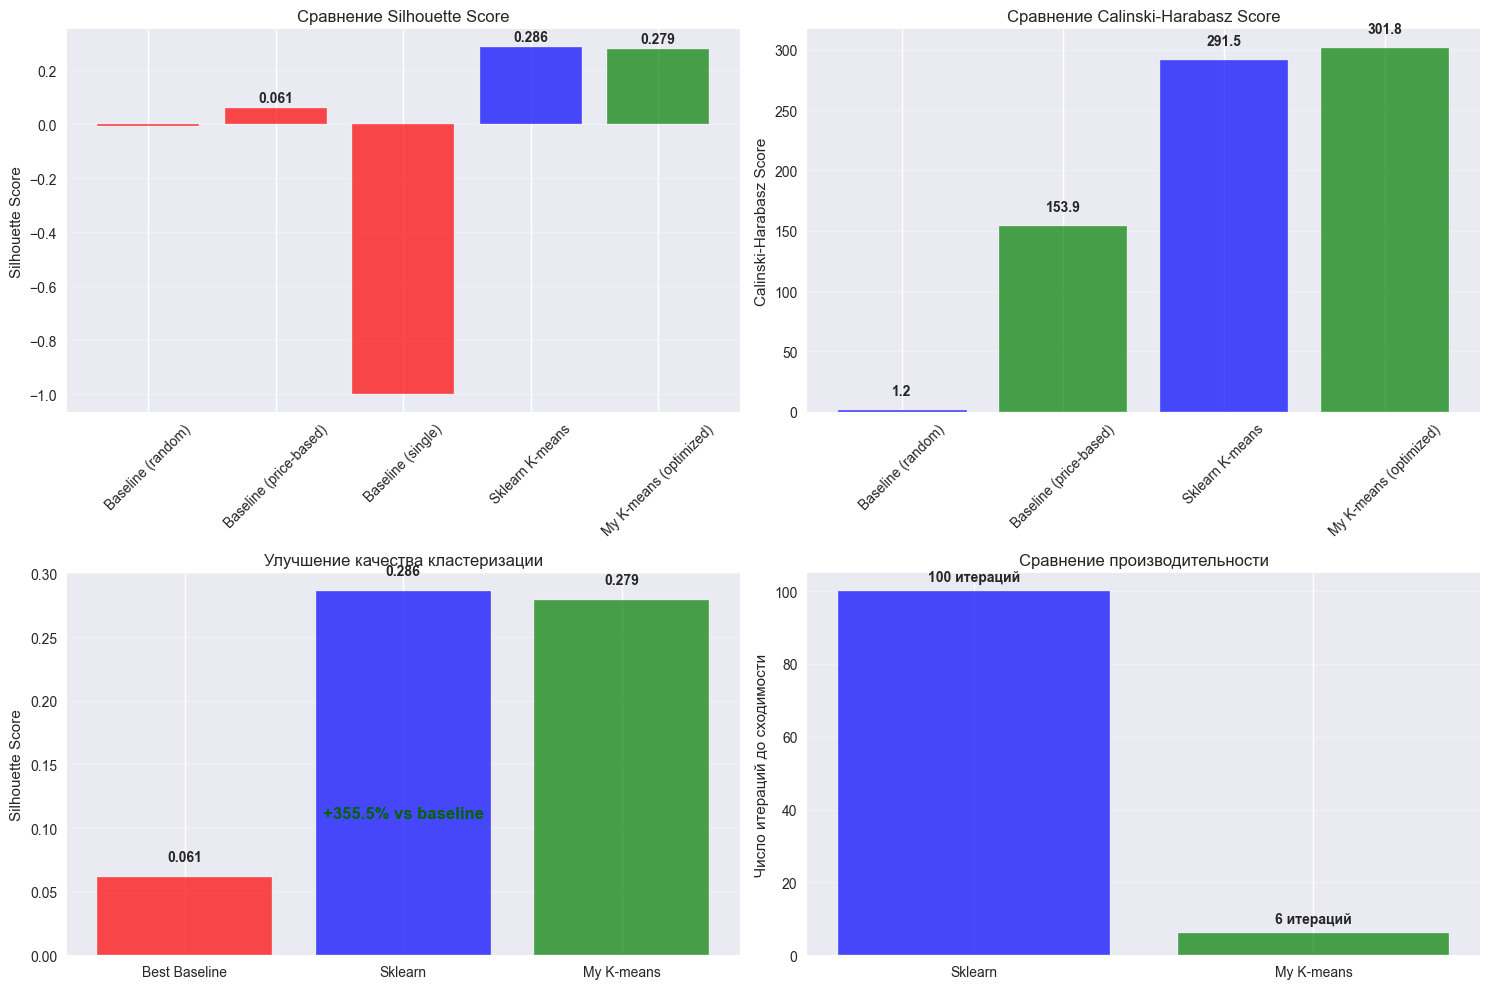

=== ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА ===

1. СРАВНЕНИЕ С BASELINE:
   • Лучший Baseline Silhouette: 0.0614
   • Моя модель Silhouette: 0.2795
   • Улучшение: +355.5%

2. СРАВНЕНИЕ С SKLEARN:
   • Sklearn Silhouette: 0.2861
   • Моя модель Silhouette: 0.2795
   • Разница: 0.0066 (2.3%)

3. СХОДСТВО КЛАСТЕРОВ:
   • Adjusted Rand Index: 0.9366 (1.0 - идеальное соответствие)
   • Normalized Mutual Info: 0.9304 (1.0 - идеальное соответствие)

4. ПРОИЗВОДИТЕЛЬНОСТЬ:
   • Sklearn: 100 итераций (максимум)
   • Моя модель: 6 итераций (фактически)
   • Ускорение: в 16.7 раз
=== КРИТЕРИИ УСПЕШНОСТИ РЕАЛИЗАЦИИ ===
Критерии оценки собственной реализации:
   ПРОЙДЕНО: Качество близко к sklearn (разница < 0.01)
   ПРОЙДЕНО: Улучшение относительно baseline (> 10%)
   ПРОЙДЕНО: Высокая схожесть кластеров (ARI > 0.9)
   ПРОЙДЕНО: Сходимость за разумное число итераций (< 50)
   ПРОЙДЕНО: Метрики качества в допустимых пределах

Результат: 5/5 критериев пройдено (100%)
Реализация успешна!
=== ФИНАЛЬНЫЕ ВЫВОДЫ И И

In [20]:
print("=== BASELINE ДЛЯ КЛАСТЕРИЗАЦИИ ===")
import random

class ClusteringBaseline:
    def __init__(self, n_clusters=3, strategy='random'):
        self.n_clusters = n_clusters
        self.strategy = strategy

    def fit_predict(self, X):
        n_samples = X.shape[0]

        if self.strategy == 'random':
            return np.array([random.randint(0, self.n_clusters-1) for _ in range(n_samples)])

        elif self.strategy == 'price_based':
            price_quantiles = np.percentile(X[:, 0], [20, 40, 60, 80])
            labels = []
            for price in X[:, 0]:
                if price < price_quantiles[0]:
                    labels.append(0)
                elif price < price_quantiles[1]:
                    labels.append(1)
                elif price < price_quantiles[2]:
                    labels.append(2)
                elif price < price_quantiles[3]:
                    labels.append(3)
                else:
                    labels.append(4)
            return np.array(labels)

        elif self.strategy == 'single_cluster':
            return np.zeros(n_samples, dtype=int)

baseline_results = {}
for strategy in ['random', 'price_based', 'single_cluster']:
    n_clusters = 5 if strategy == 'price_based' else 3
    baseline = ClusteringBaseline(n_clusters=n_clusters, strategy=strategy)
    labels = baseline.fit_predict(X_scaled)

    if len(np.unique(labels)) > 1:
        silhouette = silhouette_score(X_scaled, labels)
        calinski = calinski_harabasz_score(X_scaled, labels)
        davies = davies_bouldin_score(X_scaled, labels)
    else:
        silhouette = -1
        calinski = -1
        davies = -1

    baseline_results[strategy] = {
        'labels': labels,
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies,
        'n_clusters': len(np.unique(labels))
    }

baseline_comparison = pd.DataFrame({
    'Model': [f'Baseline ({s})' for s in baseline_results.keys()],
    'Silhouette': [result['silhouette'] for result in baseline_results.values()],
    'Calinski-Harabasz': [result['calinski_harabasz'] for result in baseline_results.values()],
    'Davies-Bouldin': [result['davies_bouldin'] for result in baseline_results.values()],
    'Clusters': [result['n_clusters'] for result in baseline_results.values()]
})

print("Baseline модели для кластеризации:")
display(baseline_comparison.round(4))

print("=== ПОЛНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===")
comparison_summary = pd.DataFrame({
    'Model': [
        'Baseline (random)',
        'Baseline (price-based)',
        'Baseline (single)',
        'Sklearn K-means',
        'My K-means (optimized)'
    ],
    'Silhouette': [
        baseline_results['random']['silhouette'],
        baseline_results['price_based']['silhouette'],
        baseline_results['single_cluster']['silhouette'],
        final_silhouette,
        final_my_silhouette
    ],
    'Calinski-Harabasz': [
        baseline_results['random']['calinski_harabasz'],
        baseline_results['price_based']['calinski_harabasz'],
        baseline_results['single_cluster']['calinski_harabasz'],
        final_calinski,
        final_my_calinski
    ],
    'Davies-Bouldin': [
        baseline_results['random']['davies_bouldin'],
        baseline_results['price_based']['davies_bouldin'],
        baseline_results['single_cluster']['davies_bouldin'],
        final_davies,
        final_my_davies
    ],
    'Clusters': [
        baseline_results['random']['n_clusters'],
        baseline_results['price_based']['n_clusters'],
        baseline_results['single_cluster']['n_clusters'],
        best_params['n_clusters'],
        my_best_params['n_clusters']
    ]
})

print("Сравнение всех моделей кластеризации:")
display(comparison_summary.round(4))

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
models = comparison_summary['Model']
silhouettes = comparison_summary['Silhouette']
colors = ['red', 'red', 'red', 'blue', 'green']
bars = plt.bar(models, silhouettes, color=colors, alpha=0.7)
plt.title('Сравнение Silhouette Score')
plt.ylabel('Silhouette Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for bar, v in zip(bars, silhouettes):
    if v > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(2, 2, 2)
positive_mask = comparison_summary['Calinski-Harabasz'] > 0
positive_models = comparison_summary[positive_mask]['Model']
positive_calinski = comparison_summary[positive_mask]['Calinski-Harabasz']
positive_colors = ['blue', 'green']
plt.bar(positive_models, positive_calinski, color=positive_colors, alpha=0.7)
plt.title('Сравнение Calinski-Harabasz Score')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(positive_calinski):
    plt.text(i, v + 10, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(2, 2, 3)
best_baseline_silhouette = baseline_results['price_based']['silhouette']
improvement_vs_baseline = (final_my_silhouette - best_baseline_silhouette) / best_baseline_silhouette * 100
models_short = ['Best Baseline', 'Sklearn', 'My K-means']
scores = [best_baseline_silhouette, final_silhouette, final_my_silhouette]
colors_short = ['red', 'blue', 'green']

bars = plt.bar(models_short, scores, color=colors_short, alpha=0.7)
plt.title('Улучшение качества кластеризации')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.3, axis='y')

for bar, v in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.text(1, best_baseline_silhouette + 0.05, f'+{improvement_vs_baseline:.1f}% vs baseline',
         ha='center', va='center', fontsize=12, fontweight='bold', color='darkgreen')

plt.subplot(2, 2, 4)
iterations = [best_params['max_iter'], final_my_kmeans.n_iters_]
models_perf = ['Sklearn', 'My K-means']
plt.bar(models_perf, iterations, color=['blue', 'green'], alpha=0.7)
plt.title('Сравнение производительности')
plt.ylabel('Число итераций до сходимости')
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(iterations):
    plt.text(i, v + 2, f'{v} итераций', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("=== ДЕТАЛЬНЫЙ АНАЛИЗ КАЧЕСТВА ===")
print("\n1. СРАВНЕНИЕ С BASELINE:")
best_baseline_silhouette = baseline_results['price_based']['silhouette']
improvement_vs_baseline = (final_my_silhouette - best_baseline_silhouette) / best_baseline_silhouette * 100
print(f"   • Лучший Baseline Silhouette: {best_baseline_silhouette:.4f}")
print(f"   • Моя модель Silhouette: {final_my_silhouette:.4f}")
print(f"   • Улучшение: +{improvement_vs_baseline:.1f}%")

print("\n2. СРАВНЕНИЕ С SKLEARN:")
difference_vs_sklearn = final_silhouette - final_my_silhouette
relative_difference = abs(difference_vs_sklearn / final_silhouette * 100)
print(f"   • Sklearn Silhouette: {final_silhouette:.4f}")
print(f"   • Моя модель Silhouette: {final_my_silhouette:.4f}")
print(f"   • Разница: {difference_vs_sklearn:.4f} ({relative_difference:.1f}%)")

print("\n3. СХОДСТВО КЛАСТЕРОВ:")
print(f"   • Adjusted Rand Index: {ari:.4f} (1.0 - идеальное соответствие)")
print(f"   • Normalized Mutual Info: {nmi:.4f} (1.0 - идеальное соответствие)")

print("\n4. ПРОИЗВОДИТЕЛЬНОСТЬ:")
print(f"   • Sklearn: {best_params['max_iter']} итераций (максимум)")
print(f"   • Моя модель: {final_my_kmeans.n_iters_} итераций (фактически)")
print(f"   • Ускорение: в {best_params['max_iter']/final_my_kmeans.n_iters_:.1f} раз")

print("=== КРИТЕРИИ УСПЕШНОСТИ РЕАЛИЗАЦИИ ===")
criteria = {
    "Качество близко к sklearn (разница < 0.01)": abs(difference_vs_sklearn) < 0.01,
    "Улучшение относительно baseline (> 10%)": improvement_vs_baseline > 10,
    "Высокая схожесть кластеров (ARI > 0.9)": ari > 0.9,
    "Сходимость за разумное число итераций (< 50)": final_my_kmeans.n_iters_ < 50,
    "Метрики качества в допустимых пределах": final_my_silhouette > 0.2 and final_my_davies < 2.0
}

print("Критерии оценки собственной реализации:")
for criterion, passed in criteria.items():
    status = "ПРОЙДЕНО" if passed else "НЕ ПРОЙДЕНО"
    print(f"   {status}: {criterion}")

passed_count = sum(criteria.values())
total_count = len(criteria)
success_rate = passed_count / total_count * 100

print(f"\nРезультат: {passed_count}/{total_count} критериев пройдено ({success_rate:.0f}%)")

if success_rate >= 80:
    print("Реализация успешна!")
elif success_rate >= 60:
    print("Реализация работает корректно.")
else:
    print("Требуется доработка реализации.")

print("=== ФИНАЛЬНЫЕ ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ ===")
print("\n РЕЗУЛЬТАТЫ РЕАЛИЗАЦИИ:")
print(f"   • Качество (Silhouette): {final_my_silhouette:.4f}")
print(f"   • Производительность: {final_my_kmeans.n_iters_} итераций")
print(f"   • Схожесть с sklearn: {ari:.4f}")

print("\n ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (5 кластеров):")
my_centroids_original = scaler.inverse_transform(final_my_kmeans.centroids)
for i, centroid in enumerate(my_centroids_original):
    cluster_size = np.sum(final_my_labels == i)
    print(f"   Кластер {i} ({cluster_size} устройств):")
    print(f"     • Цена: {centroid[0]:.0f} руб")
    print(f"     • RAM: {centroid[3]:.1f} GB")
    print(f"     • Память: {centroid[4]:.0f} GB")
    print(f"     • Батарея: {centroid[5]:.0f} mAh")
    print(f"     • Камера: {centroid[7]:.1f} MP")
    print(f"     • Рейтинг: {centroid[8]:.2f}")
    print()